## Author: Jeremiah Olamijuwon
## Organization: Etihuku Pty Ltd
## Date: 29th August, 2024

# Quick Exercise

### Shall we share a sum of E250,000

In [4]:
# Performance Evaluation

## Have a look at below image, what do you see?

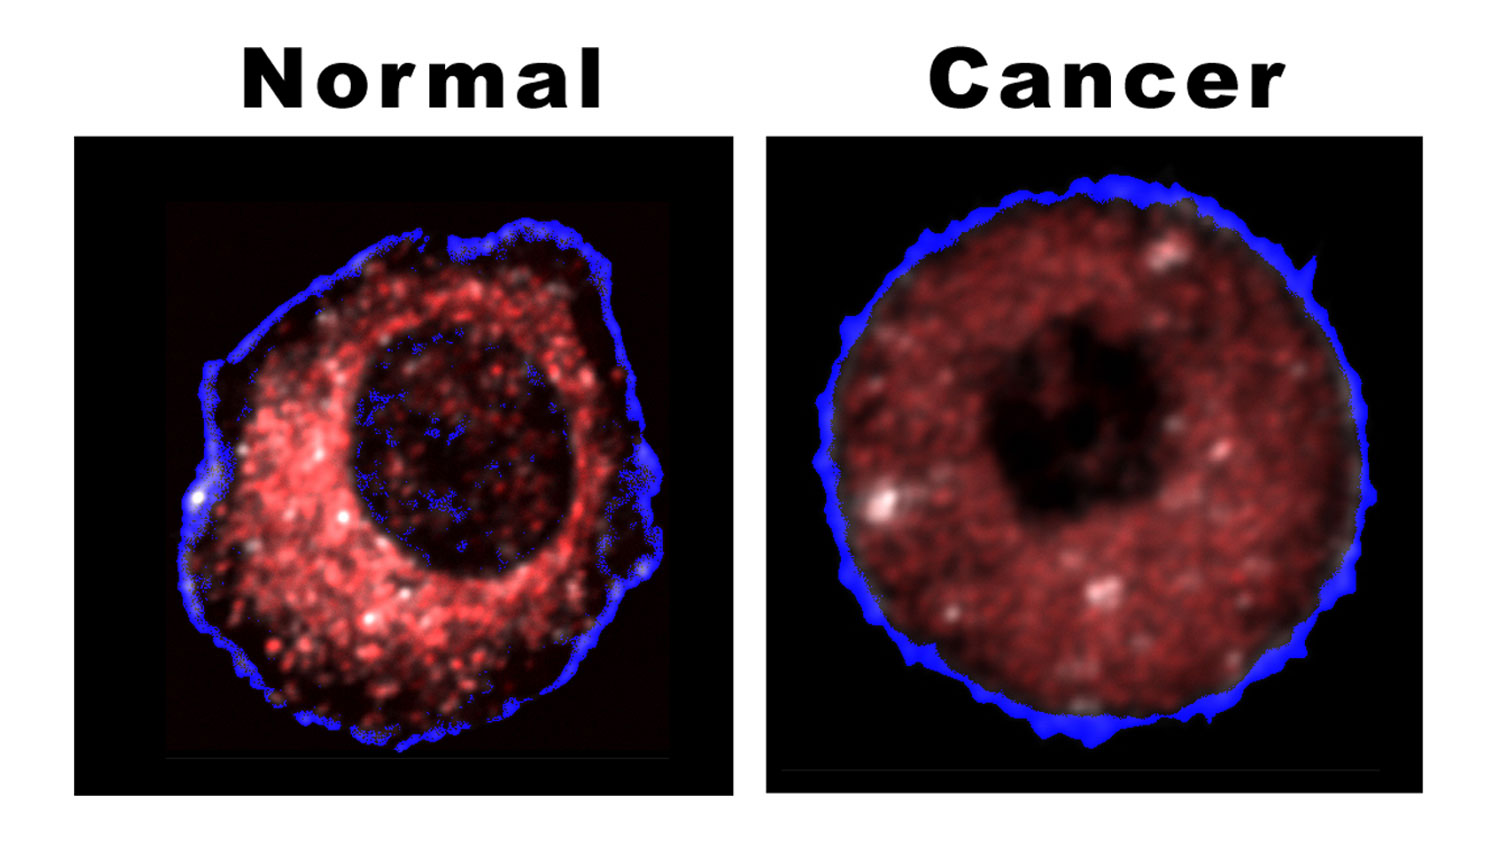

In [5]:
%pip install scikit-learn
%pip install lime
%pip install matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [6]:
from sklearn import datasets
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import lime
import pandas as pd

In [7]:
iris = datasets.load_iris()
iris.keys()
# # iris.data[:, 0]

# iris.feature_names[1]
# iris.target

# iris.data[:, 1]

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [8]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [9]:
X, y = datasets.load_iris(return_X_y=True) 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [10]:
X_train[0]

array([4.6, 3.6, 1. , 0.2])

In [11]:
plt.rcParams["image.cmap"] = "Set1"
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Set1.colors)

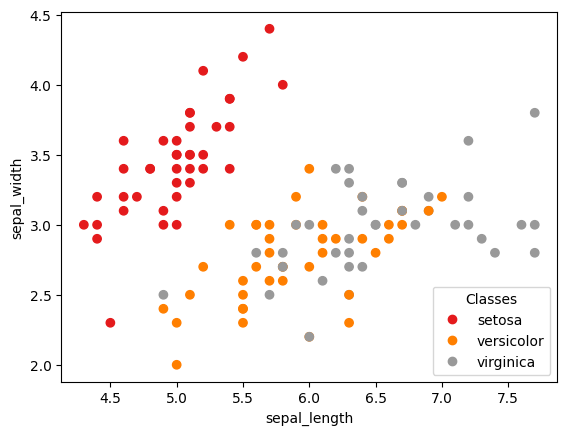

In [12]:
df = pd.DataFrame(X_train, columns=['sepal_length','sepal_width', 'petal_length', 'petal_width'])
df['species'] = y_train
target_names = ['setosa', 'versicolor', 'virginica']
x_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
y_columns = ['species']

_, ax = plt.subplots()
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
ax.set(xlabel=x_columns[0], ylabel=x_columns[1])
_ = ax.legend(   
    scatter.legend_elements()[0], target_names, loc="lower right", title="Classes"
)

In [13]:
test_df = pd.DataFrame(X_test, columns=['sepal_length','sepal_width', 'petal_length', 'petal_width'])
# test_df['species'] = y_test

In [14]:
test_df['quick_label'] = y_test
vvv = test_df[test_df.quick_label == 1]

In [15]:
import random
[random.uniform(min(vvv.sepal_length), max(vvv.sepal_length)), random.uniform(min(vvv.sepal_width), max(vvv.sepal_width)),
 random.uniform(min(vvv.petal_length), max(vvv.petal_length)), random.uniform(min(vvv.petal_width), max(vvv.petal_width))]

[5.833102763420166, 2.5951707191451883, 4.339194570683512, 1.4941026225970495]

In [16]:
min(vvv.sepal_width)

2.2

In [17]:
test_df.sepal_length

0     6.1
1     5.7
2     7.7
3     6.0
4     6.8
5     5.4
6     5.6
7     6.9
8     6.2
9     5.8
10    6.5
11    4.8
12    5.5
13    4.9
14    5.1
15    6.3
16    6.5
17    5.6
18    5.7
19    6.4
20    4.7
21    6.1
22    5.0
23    6.4
24    7.9
25    6.7
26    6.7
27    6.8
28    4.8
29    4.8
Name: sepal_length, dtype: float64

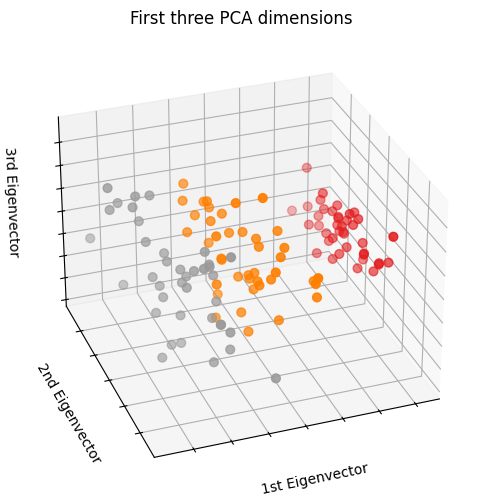

In [18]:
from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

X_reduced = PCA(n_components=3).fit_transform(X_train)
ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=y_train,
    s=40,
)

ax.set_title("First three PCA dimensions")
ax.set_xlabel("1st Eigenvector")
ax.xaxis.set_ticklabels([])
ax.set_ylabel("2nd Eigenvector")
ax.yaxis.set_ticklabels([])
ax.set_zlabel("3rd Eigenvector")
ax.zaxis.set_ticklabels([])

plt.show()

In [19]:
score = model.score(X_test, y_test)
print(f"Score method - Accuracy: {score}")

Score method - Accuracy: 1.0


In [20]:
X_test[0]

array([6.1, 2.8, 4.7, 1.2])

In [21]:
y_test[0]

1

In [22]:
model.predict(X_test[0][np.newaxis])

array([1])

The model we trained says it's decision is 1 (versicolor). But how did it arrive at this decision?

Can we trust its decision always? How has it learned from the training data and what kind of experience has it learned?

# Explainable Artificial Intelligence (XAI)

Explainable artificial intelligence (XAI) refers to a collection of procedures and techniques that enable machine learning algorithms to produce output and results that are understandable and reliable for human users.

One of those techniques is Local Interpretable Model-agnostic Explanations (LIME).

Another common technique is the SHapley Additive exPlanations (SHAP).

One other common technique is Explain Like I'm 5 (ELI5)

Now, let's explore LIME.

First, we are going to create a LIME explainer instance using the LimeTabularExplainer class from the lime.lime_tabular module. We will also initialize the explainer with the feature names and class names of the iris dataset so that the LIME explanation can use these names to interpret the factors that contributed to the predicted class of the instance being explained.

In [25]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
  X, 
  feature_names=['sepal length', 'sepal width', 'petal length', 'petal width'], 
  class_names=['setosa', 'versicolor', 'virginica']
)

In [26]:
X_test[0]

array([6.1, 2.8, 4.7, 1.2])

In [27]:
exp = explainer.explain_instance(X_test[0], model.predict_proba, num_features=4)
exp.show_in_notebook()

In [ ]:
X_test[0], x_columns

(array([6.1, 2.8, 4.7, 1.2]),
 ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])

## Very cool stuff, right?

### But wait! How did LIME do that?

# Understanding LIME (Local Interpretable Model-agnostic Explanations)

LIME (Local Interpretable Model-agnostic Explanations) is a technique used to explain the predictions of machine learning models. It works by approximating the model's behavior in the vicinity of a specific prediction with a simpler, interpretable model, such as a linear regression model. This approximation is done locally around the data point being explained.

How LIME Works

1. Choose a Data Point: Select a data point for which you want to understand the model's prediction.
2. Generate Perturbations: Create a set of perturbed samples around this data point. These are slightly altered versions of the original data point.
3. Predict Perturbations: Use the original model to predict the outcomes for these perturbed samples.
4. Fit an Interpretable Model: Train a simpler, interpretable model (like a linear model) on the perturbed samples and their predictions. This interpretable model approximates the behavior of the complex model locally.
5. Explain the Prediction: The coefficients of the interpretable model provide insights into how the original model arrived at its prediction for the chosen data point.

In [28]:
def lime_explain(instance, model, X_train, feature_names: list[str], num_samples=1000, kernel_width=0.1,):
    # Generate perturbed samples
    perturbed_samples = np.random.normal(loc=instance, scale=kernel_width, size=(num_samples, len(instance)))
     
    # Predict on perturbed samples
    predictions = model.predict(perturbed_samples)
    
    # Create a DataFrame for the perturbed samples
    perturbed_df = pd.DataFrame(perturbed_samples, columns=feature_names)
    perturbed_df['prediction'] = predictions
    
    # Train a linear model
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import LinearRegression

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(perturbed_samples)
    
    linear_model = LinearRegression()
    linear_model.fit(X_scaled, predictions)
    
    # Get coefficients
    coefficients = linear_model.coef_
    return coefficients


In [29]:
# Choose a data point to explain
instance = X_test[0]
feature_names = x_columns

# Get explanation
coefficients = lime_explain(instance, model, X_train, feature_names)

# Display the explanation
explanation = pd.DataFrame(coefficients, index=x_columns, columns=['Coefficient'])
print("LIME Explanation for the instance:")
print(explanation)


LIME Explanation for the instance:
              Coefficient
sepal_length     0.000374
sepal_width     -0.000116
petal_length     0.005478
petal_width      0.001483


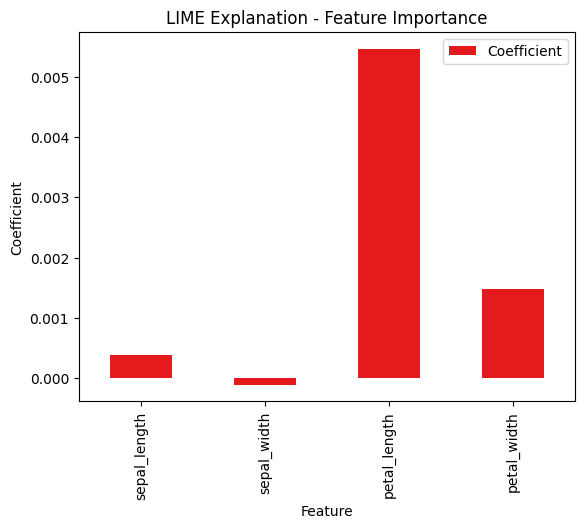

In [30]:
# Plot the feature importance
explanation.plot(kind='bar')
plt.title('LIME Explanation - Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.show()


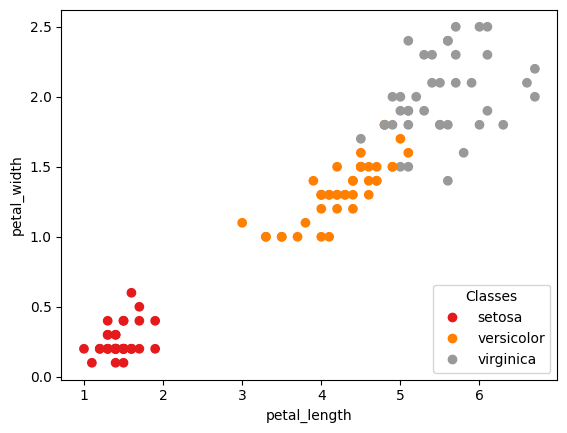

In [31]:
df = pd.DataFrame(X_train, columns=['sepal_length','sepal_width', 'petal_length', 'petal_width'])
df['species'] = y_train
target_names = ['setosa', 'versicolor', 'virginica']
x_columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
y_columns = ['species']

_, ax = plt.subplots()
scatter = ax.scatter(X_train[:, 2], X_train[:, 3], c=y_train)
ax.set(xlabel=x_columns[2], ylabel=x_columns[3])
_ = ax.legend(
    scatter.legend_elements()[0], target_names, loc="lower right", title="Classes"
)

### Explanation

- Perturbation Generation: The function creates new samples around the instance by adding noise (Gaussian perturbation) to the features. This simulates how the model's predictions might change if the data point were slightly different.

- Prediction on Perturbations: The complex model predicts outcomes for these perturbed samples.

- Linear Model Fitting: A linear regression model is then trained on the perturbed samples and their predictions to understand the relationship between features and predictions locally.

### Quick run through of the coefficients:
- Sepal Length (-0.001293): This coefficient indicates a very slight negative impact of the sepal length on the prediction. A small increase in sepal length would lead to a tiny decrease in the prediction score.

- Sepal Width (-0.000996): Similar to sepal length, this coefficient shows a small negative effect of sepal width on the prediction.

- Petal Length (0.005594): This coefficient is positive, suggesting that an increase in petal length would lead to a slight increase in the prediction score. It has a slightly larger magnitude compared to the other features.

- Petal Width (0.002321): This coefficient is also positive, indicating that an increase in petal width contributes positively to the prediction score.

### Interpretation

- Magnitude of Coefficients: The magnitude of each coefficient reflects the strength of the feature’s impact on the prediction. Larger absolute values indicate a more significant impact.

- Sign of Coefficients: Positive coefficients indicate that higher values of the feature increase the prediction score, while negative coefficients suggest a decrease.

In [ ]:
# !pip install shap

In [32]:
import shap
import matplotlib.pyplot as plt

# load JS visualization code to notebook
shap.initjs()

# Create the explainer
explainer = shap.KernelExplainer(model.predict_proba, X_train)

shap_values = explainer.shap_values(test_df.iloc[0, :-1])

Using 120 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


In [33]:
shap.force_plot(explainer.expected_value[0], shap_values[:, 0], test_df.iloc[0, :-1])

In [34]:
shap_values = explainer.shap_values(test_df.iloc[:, :-1])
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], test_df.iloc[:, :-1])

  0%|          | 0/30 [00:00<?, ?it/s]

### Notice that in the image, you can interact with the plot. As you move across the plot, you will see some details about each point in the test data. You can also click on the drop down in the plot to see what the plot looks like if you were to view from a different perspective. For example, selecting petal_length in the plot above will show you what the test records look like petal_length wise and where they fall in the explanation.

## Note also that you can use other models to build your explainer, same way you can use any machine learning model to learn your data, depending on the type of data.

## For example, here's how you would use SHAP with a simple MLP

In [35]:
from sklearn.neural_network import MLPClassifier

nn = MLPClassifier(solver="lbfgs", alpha=1e-1, hidden_layer_sizes=(5, 2), random_state=0)
nn.fit(X_train, y_train)

# explain all the predictions in the test set
explainer = shap.KernelExplainer(nn.predict_proba, X_train)
shap_values = explainer.shap_values(test_df.iloc[:, :-1])
shap.force_plot(explainer.expected_value[0], shap_values[..., 0], test_df.iloc[:, :-1])

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
Using 120 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/30 [00:00<?, ?it/s]

## Some limitations to XAI

- Computational Demands: Many explainable AI (XAI) techniques are computationally intensive and require substantial resources and processing power to generate and interpret their results. This high computational demand can pose challenges for real-time applications and large-scale systems, potentially limiting the practicality and deployment of XAI in these scenarios.

- Limited Applicability and Domain Constraints: Various XAI methods are often constrained by their scope and are tailored to specific domains, making them less applicable to all types of machine learning models and use cases. This restricted applicability can hinder the adoption and versatility of XAI across different fields and applications.

- No Standardization and Compatibility: The field of XAI currently lacks uniform standards and interoperability, with different methods employing varied metrics, algorithms, and frameworks. This lack of standardization complicates the comparison and evaluation of different XAI approaches and can restrict their broader use and integration across diverse domains and applications.

# Footnotes

## Some of the attendees requested for some links to learn about Machine Learning. While there are a plethora of materials out there, here are some from our Indaba Community that I can recommend.

- https://github.com/deep-learning-indaba/indaba-pracs-2024/blob/main/practicals/Intro_to_ML_using_JAX/Introduction_to_ML_using_JAX.ipynb
- https://github.com/deep-learning-indaba/indaba-pracs-2024/blob/main/practicals/Foundations_of_LLMs/foundations_of_llms_practical.ipynb

## Other materials are listed below:
- https://www.geeksforgeeks.org/introduction-machine-learning/
- https://www.geeksforgeeks.org/introduction-machine-learning-using-python/
- https://www.geeksforgeeks.org/machine-learning-with-python/